In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar100

# TensorFlow places every op on the GPU automatically when it can see one —
# on Colab, just make sure Runtime > Change runtime type is set to a GPU.
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Devices: {[d.device_type for d in tf.config.list_physical_devices()]}")

# Re-applied before every training run, so each model starts from an identical
# initialisation and the comparisons below are about architecture, not luck.
SEED = 42
tf.keras.utils.set_random_seed(SEED)

TensorFlow version: 2.20.0
GPU available: True
Devices: ['CPU', 'GPU']


In [3]:
import numpy as np
d = np.load('cifar100.npz')

x_train = d['x_train'].astype("float32") / 255.0
x_test  = d['x_test'].astype("float32")  / 255.0

y_train = keras.utils.to_categorical(d['y_train'], 100)
y_test  = keras.utils.to_categorical(d['y_test'],  100)

class_names = list(d['class_names'])

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape},  y_test:  {y_test.shape}")
print(f"{len(class_names)} classes, {len(x_train) // len(class_names)} training images each")

x_train: (50000, 32, 32, 3), y_train: (50000, 100)
x_test:  (10000, 32, 32, 3),  y_test:  (10000, 100)
100 classes, 500 training images each


In [4]:
# (x_train, y_train), (x_test, y_test) = cifar100.load_data()

# x_train = x_train.astype("float32") / 255.0
# x_test  = x_test.astype("float32")  / 255.0

# y_train = keras.utils.to_categorical(y_train, 100)
# y_test  = keras.utils.to_categorical(y_test,  100)

# class_names = [
#     'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
#     'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
#     'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
#     'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
#     'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
#     'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
#     'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
#     'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
#     'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
#     'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
#     'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
#     'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank',
#     'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
#     'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm',
# ]

# print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
# print(f"x_test:  {x_test.shape},  y_test:  {y_test.shape}")
# print(f"{len(class_names)} classes, {len(x_train) // len(class_names)} training images each")

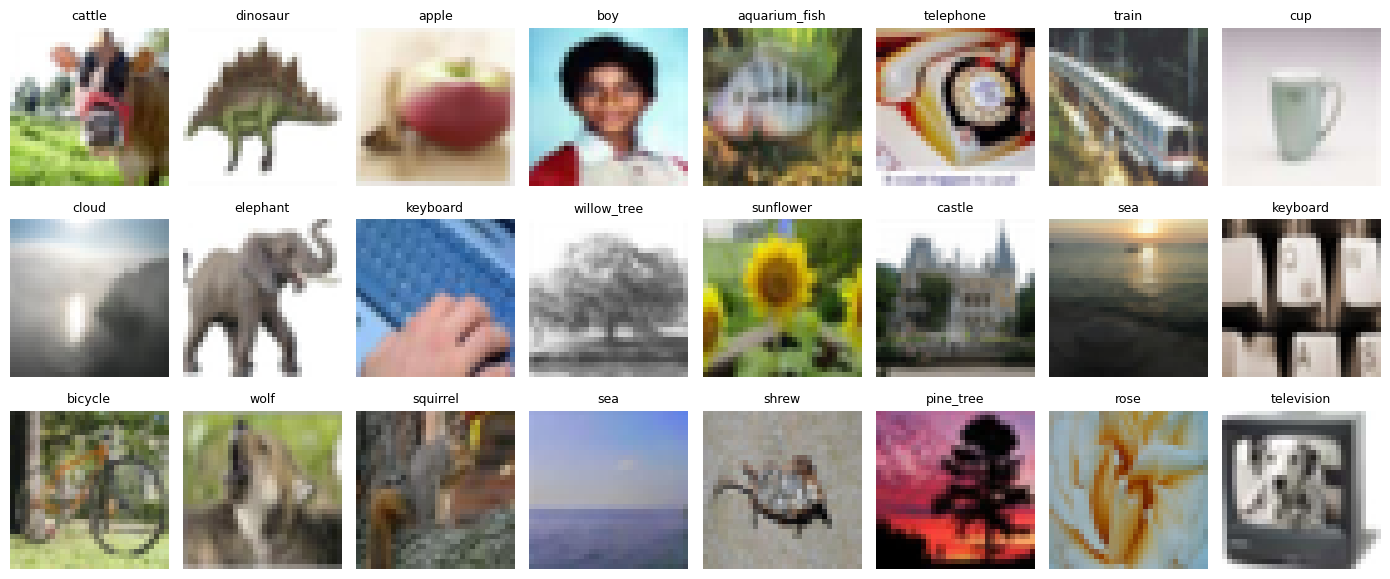

In [5]:
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(np.argmax(y_train[i]))], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
results = []   # one row per trained model; printed as a scoreboard in Part 5


def report(name, model, history):
    # Record the scoreboard row for a trained model, then plot its learning curves.
    h = history.history
    results.append({
        'model':     name,
        'params':    model.count_params(),
        'epochs':    len(h['loss']),
        'train_acc': h['accuracy'][-1],
        'test_acc':  h['val_accuracy'][-1],
        'gap':       h['accuracy'][-1] - h['val_accuracy'][-1],
    })
    r = results[-1]
    print(f"{name}  |  {r['params']:,} params  |  train {r['train_acc']:.3f}  "
          f"|  test {r['test_acc']:.3f}  |  gap {r['gap']:+.3f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(h['accuracy'],     label='train')
    ax1.plot(h['val_accuracy'], label='test')
    ax1.set_title(f'{name} — accuracy')
    ax2.plot(h['loss'],     label='train')
    ax2.plot(h['val_loss'], label='test')
    ax2.set_title(f'{name} — loss')
    for ax in (ax1, ax2):
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


BATCH_SIZE = 128

# Part 1: A Simple CNN

In [8]:
tf.keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=(32, 32, 3), name='image')

# Block 1
x = layers.Conv2D(32, kernel_size=3, padding='same',  activation='relu')(inputs)  # 32 x 32 x 32
x = layers.Conv2D(32, kernel_size=3, padding='valid', activation='relu')(x)       # 30 x 30 x 32
x = layers.MaxPooling2D(pool_size=2)(x)                                           # 15 x 15 x 32

# Block 2
x = layers.Conv2D(64, kernel_size=3, padding='same',  activation='relu')(x)       # 15 x 15 x 64
x = layers.Conv2D(64, kernel_size=3, padding='valid', activation='relu')(x)       # 13 x 13 x 64
x = layers.MaxPooling2D(pool_size=2)(x)                                           #  6 x  6 x 64

# Classifier head
x = layers.Flatten()(x)                                                           # 6*6*64 = 2304
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(100, activation='softmax', name='probs')(x)

cnn = keras.Model(inputs, outputs, name='simple_cnn')
cnn.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,508 (1.42 MB)

 Trainable params: 373,508 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print("\n=== Training: Simple CNN (Flatten head) ===")
history = cnn.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=BATCH_SIZE,
    verbose=2,
)


=== Training: Simple CNN (Flatten head) ===
Epoch 1/20
391/391 - 14s - 36ms/step - accuracy: 0.0939 - loss: 3.9838 - val_accuracy: 0.1728 - val_loss: 3.5384
Epoch 2/20
391/391 - 4s - 10ms/step - accuracy: 0.2114 - loss: 3.2713 - val_accuracy: 0.2471 - val_loss: 3.1101
Epoch 3/20
391/391 - 4s - 10ms/step - accuracy: 0.2792 - loss: 2.9102 - val_accuracy: 0.2861 - val_loss: 2.9103
Epoch 4/20
391/391 - 4s - 9ms/step - accuracy: 0.3308 - loss: 2.6494 - val_accuracy: 0.3247 - val_loss: 2.7173
Epoch 5/20
391/391 - 4s - 9ms/step - accuracy: 0.3726 - loss: 2.4531 - val_accuracy: 0.3507 - val_loss: 2.5839
Epoch 6/20
391/391 - 4s - 10ms/step - accuracy: 0.4064 - loss: 2.2956 - val_accuracy: 0.3719 - val_loss: 2.4950
Epoch 7/20
391/391 - 4s - 9ms/step - accuracy: 0.4346 - loss: 2.1657 - val_accuracy: 0.3792 - val_loss: 2.4621
Epoch 8/20
391/391 - 4s - 9ms/step - accuracy: 0.4580 - loss: 2.0574 - val_accuracy: 0.3845 - val_loss: 2.4550
Epoch 9/20
391/391 - 4s - 10ms/step - accuracy: 0.4795 - loss:

# Part 2

In [10]:
tf.keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=(32, 32, 3), name='image')

# Block 1
x = layers.Conv2D(32, kernel_size=3, padding='same',  activation='relu')(inputs)  # 32 x 32 x 32
x = layers.Conv2D(32, kernel_size=3, padding='valid', activation='relu')(x)       # 30 x 30 x 32
x = layers.MaxPooling2D(pool_size=2)(x)                                           # 15 x 15 x 32

# Block 2
x = layers.Conv2D(64, kernel_size=3, padding='same',  activation='relu')(x)       # 15 x 15 x 64
x = layers.Conv2D(64, kernel_size=3, padding='valid', activation='relu')(x)       # 13 x 13 x 64
x = layers.MaxPooling2D(pool_size=2)(x)                                           #  6 x  6 x 64

# Classifier head
x = layers.GlobalAveragePooling2D()(x)                                                                                                     # 6*6*64 = 2304
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(100, activation='softmax', name='probs')(x)

cnn = keras.Model(inputs, outputs, name='simple_cnn')
cnn.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,788 (339.02 KB)

 Trainable params: 86,788 (339.02 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print("\n=== Training: Simple CNN (GAP head) ===")
history = cnn.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=BATCH_SIZE,
    verbose=2,
)


=== Training: Simple CNN (GAP head) ===
Epoch 1/20
391/391 - 10s - 27ms/step - accuracy: 0.0509 - loss: 4.2033 - val_accuracy: 0.0786 - val_loss: 3.9728
Epoch 2/20
391/391 - 4s - 9ms/step - accuracy: 0.0988 - loss: 3.8339 - val_accuracy: 0.1144 - val_loss: 3.7134
Epoch 3/20
391/391 - 4s - 10ms/step - accuracy: 0.1338 - loss: 3.6306 - val_accuracy: 0.1547 - val_loss: 3.5370
Epoch 4/20
391/391 - 4s - 10ms/step - accuracy: 0.1641 - loss: 3.4643 - val_accuracy: 0.1773 - val_loss: 3.3898
Epoch 5/20
391/391 - 4s - 9ms/step - accuracy: 0.1925 - loss: 3.3087 - val_accuracy: 0.2008 - val_loss: 3.2631
Epoch 6/20
391/391 - 4s - 9ms/step - accuracy: 0.2206 - loss: 3.1647 - val_accuracy: 0.2199 - val_loss: 3.1410
Epoch 7/20
391/391 - 4s - 10ms/step - accuracy: 0.2431 - loss: 3.0384 - val_accuracy: 0.2338 - val_loss: 3.0464
Epoch 8/20
391/391 - 4s - 9ms/step - accuracy: 0.2624 - loss: 2.9334 - val_accuracy: 0.2500 - val_loss: 2.9799
Epoch 9/20
391/391 - 4s - 9ms/step - accuracy: 0.2783 - loss: 2.85

# Part 3

In [12]:
tf.keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=(32, 32, 3), name='image')

# Block 1
x = layers.Conv2D(64,  kernel_size=3, padding='same', activation='relu')(inputs)  # 32 x 32 x 64
x = layers.Conv2D(64,  kernel_size=3, padding='same', activation='relu')(x)       # 32 x 32 x 64
x = layers.MaxPooling2D(pool_size=2)(x)                                           # 16 x 16 x 64

# Block 2
x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)       # 16 x 16 x 128
x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)       # 16 x 16 x 128
x = layers.MaxPooling2D(pool_size=2)(x)                                           #  8 x  8 x 128

# Block 3
x = layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)       #  8 x  8 x 256
x = layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)       #  8 x  8 x 256
x = layers.MaxPooling2D(pool_size=2)(x)                                           #  4 x  4 x 256

# Classifier head — Flatten + a wide Dense, and NO regularisation anywhere
x = layers.Flatten()(x)                                                           # 4*4*256 = 4096
x = layers.Dense(512, activation='relu')(x)
outputs = layers.Dense(100, activation='softmax', name='probs')(x)

cnn = keras.Model(inputs, outputs, name='big_cnn')
cnn.summary()

Model: "big_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,294,372 (12.57 MB)

 Trainable params: 3,294,372 (12.57 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print("\n=== Training: Bigger CNN (no regularisation) ===")
history = cnn.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=BATCH_SIZE,
    verbose=2,
)


=== Training: Bigger CNN (no regularisation) ===
Epoch 1/30
391/391 - 27s - 68ms/step - accuracy: 0.0772 - loss: 4.0515 - val_accuracy: 0.1735 - val_loss: 3.4988
Epoch 2/30
391/391 - 11s - 29ms/step - accuracy: 0.2265 - loss: 3.1737 - val_accuracy: 0.2728 - val_loss: 2.9931
Epoch 3/30
391/391 - 11s - 29ms/step - accuracy: 0.3305 - loss: 2.6485 - val_accuracy: 0.3261 - val_loss: 2.7640
Epoch 4/30
391/391 - 11s - 29ms/step - accuracy: 0.4173 - loss: 2.2466 - val_accuracy: 0.3602 - val_loss: 2.6364
Epoch 5/30
391/391 - 11s - 29ms/step - accuracy: 0.4833 - loss: 1.9405 - val_accuracy: 0.3604 - val_loss: 2.7906
Epoch 6/30
391/391 - 11s - 29ms/step - accuracy: 0.5423 - loss: 1.6852 - val_accuracy: 0.3482 - val_loss: 3.0602
Epoch 7/30
391/391 - 11s - 29ms/step - accuracy: 0.6001 - loss: 1.4490 - val_accuracy: 0.3536 - val_loss: 3.1867
Epoch 8/30
391/391 - 11s - 29ms/step - accuracy: 0.6443 - loss: 1.2579 - val_accuracy: 0.3567 - val_loss: 3.4365
Epoch 9/30
391/391 - 11s - 29ms/step - accurac

KeyboardInterrupt: 

# Part 4

In [14]:
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),        # mirror left-right (NOT vertical, see above)
    layers.RandomRotation(0.08),            # +/- 8% of a full turn, ~29 degrees
    layers.RandomZoom(0.1),                 # in or out by up to 10%
    layers.RandomTranslation(0.08, 0.08),   # shift up to 8% of the image, h and w
    layers.RandomContrast(0.15),            # scale contrast by up to 15%
], name='augment')

# Note the parameter count: augmentation is pure computation, it learns nothing.
augment.summary()

Model: "augment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

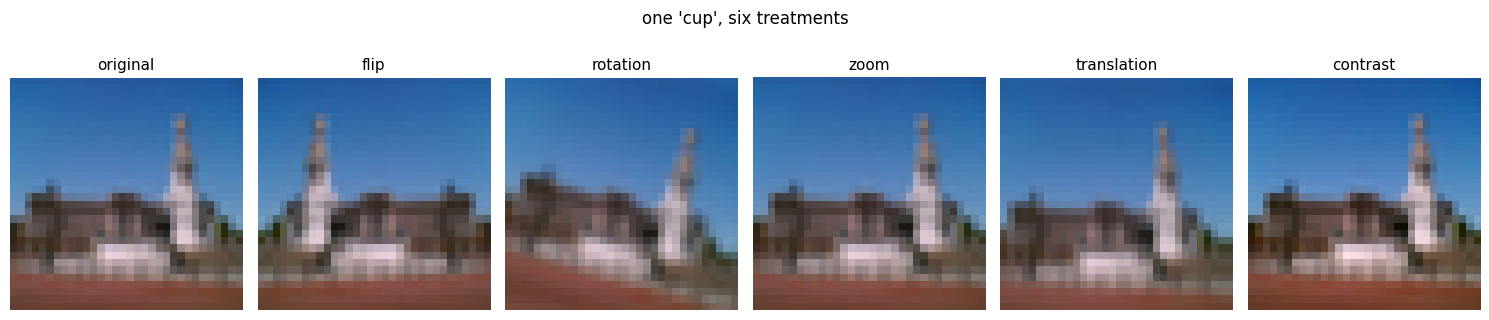

In [18]:
img = x_train[700][None, ...]          # one image, kept as a batch of 1

steps = [
    ('original',    None),
    ('flip',        layers.RandomFlip('horizontal')),
    ('rotation',    layers.RandomRotation(0.08)),
    ('zoom',        layers.RandomZoom(0.1)),
    ('translation', layers.RandomTranslation(0.08, 0.08)),
    ('contrast',    layers.RandomContrast(0.35)),
]

fig, axes = plt.subplots(1, len(steps), figsize=(15, 3))
for ax, (name, layer) in zip(axes, steps):
    shown = img if layer is None else layer(img, training=True)
    ax.imshow(np.clip(shown[0], 0, 1))
    ax.set_title(name, fontsize=11)
    ax.axis('off')
fig.suptitle(f"one '{class_names[int(np.argmax(y_train[7]))]}', six treatments", y=1.06)
plt.tight_layout()
plt.show()

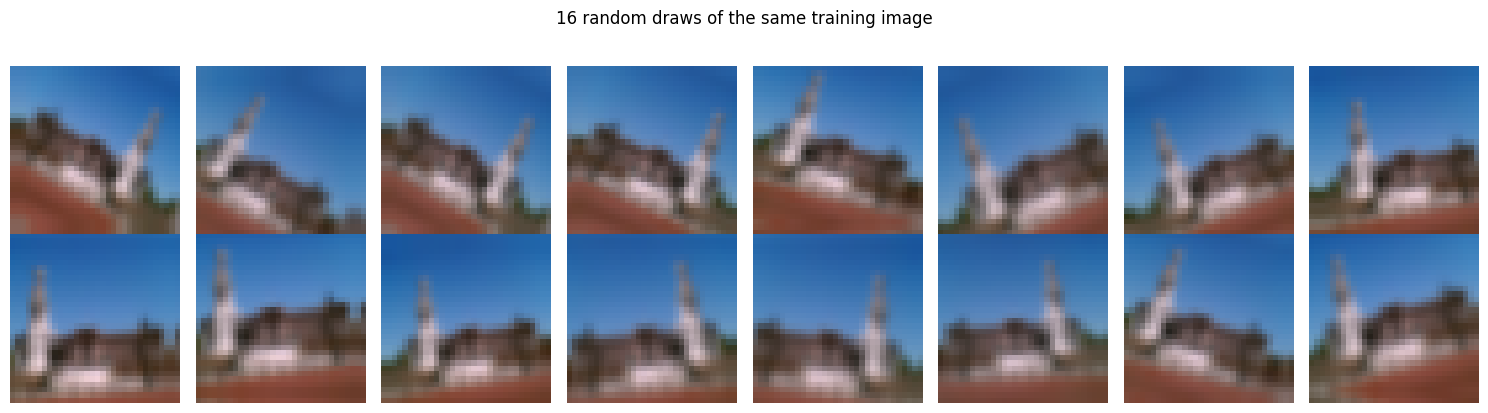

In [19]:
fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for ax in axes.flat:
    ax.imshow(np.clip(augment(img, training=True)[0], 0, 1))
    ax.axis('off')
fig.suptitle('16 random draws of the same training image', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
tf.keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=(32, 32, 3), name='image')
x = augment(inputs)                                                               # <- the only change

# Block 1
x = layers.Conv2D(64,  kernel_size=3, padding='same', activation='relu')(x)       # 32 x 32 x 64
x = layers.Conv2D(64,  kernel_size=3, padding='same', activation='relu')(x)       # 32 x 32 x 64
x = layers.MaxPooling2D(pool_size=2)(x)                                           # 16 x 16 x 64

# Block 2
x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)       # 16 x 16 x 128
x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)       # 16 x 16 x 128
x = layers.MaxPooling2D(pool_size=2)(x)                                           #  8 x  8 x 128

# Block 3
x = layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)       #  8 x  8 x 256
x = layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)       #  8 x  8 x 256
x = layers.MaxPooling2D(pool_size=2)(x)                                           #  4 x  4 x 256

# Same head as Part 3 — still no dropout, still no batch-norm
x = layers.Flatten()(x)                                                           # 4*4*256 = 4096
x = layers.Dense(512, activation='relu')(x)
outputs = layers.Dense(100, activation='softmax', name='probs')(x)

cnn = keras.Model(inputs, outputs, name='big_cnn_augmented')
cnn.summary()

Model: "big_cnn_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,294,372 (12.57 MB)

 Trainable params: 3,294,372 (12.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print("\n=== Training: Bigger CNN + augmentation ===")
history = cnn.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=BATCH_SIZE,
    verbose=2,
)


=== Training: Bigger CNN + augmentation ===
Epoch 1/30
391/391 - 18s - 47ms/step - accuracy: 0.0699 - loss: 4.0836 - val_accuracy: 0.1488 - val_loss: 3.5936
Epoch 2/30
391/391 - 12s - 30ms/step - accuracy: 0.1789 - loss: 3.4175 - val_accuracy: 0.2413 - val_loss: 3.0966
Epoch 3/30
391/391 - 12s - 30ms/step - accuracy: 0.2477 - loss: 3.0366 - val_accuracy: 0.3013 - val_loss: 2.7994
Epoch 4/30
391/391 - 12s - 29ms/step - accuracy: 0.3002 - loss: 2.7912 - val_accuracy: 0.3363 - val_loss: 2.6434
Epoch 5/30
391/391 - 11s - 29ms/step - accuracy: 0.3337 - loss: 2.6228 - val_accuracy: 0.3543 - val_loss: 2.5988
Epoch 6/30
391/391 - 12s - 30ms/step - accuracy: 0.3652 - loss: 2.4658 - val_accuracy: 0.3805 - val_loss: 2.4786
Epoch 7/30
391/391 - 11s - 29ms/step - accuracy: 0.3925 - loss: 2.3436 - val_accuracy: 0.3880 - val_loss: 2.4392
Epoch 8/30
391/391 - 11s - 29ms/step - accuracy: 0.4173 - loss: 2.2329 - val_accuracy: 0.3973 - val_loss: 2.4457
Epoch 9/30
391/391 - 11s - 29ms/step - accuracy: 0.